# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [86]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [87]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [88]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [89]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [90]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [91]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [92]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [93]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [94]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [95]:
# cantidad de nulos para users
print("Cantidad de valores nulos para df users")
print(users.isna().sum()) # Cantidad de valores nulos
print()
print("Proporción de valores nulos para df users")
print(users.isna().mean()) # Proporción de valores nulos

Cantidad de valores nulos para df users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos para df users
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [96]:
# cantidad de nulos para usage
print("Cantidad de valores nulos para df usage")
print(usage.isna().sum()) # Cantidad de valores nulos
print()
print("Proporción de valores nulos para df usage")
print(usage.isna().mean()) # Proporción de valores nulos

Cantidad de valores nulos para df usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos para df usage
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Para el df users**, se observa que la columna city tiene aprox 11% de valores nulos, se debe mantener y dejar como nulos ("unknown"). La columna churn_date contiene el 88% de nulos, lo que representa clientes activos. El 12% restante (no nulos) son clientes retirados/inactivos por lo que mantendría el registro para una posible indagación de su retiro y posible reactivación posterior. 

**Para el df usage**, se observa columnas como duration y length con porcentajes considerables de valores nulos pero que se corresponden con el tipo de registro según sea llamada o mensaje por lo que se asume como una circunstancia normal, por lo tanto, se deberían mantener como nulos o aplicarle un "N/A" según corresponda.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [97]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es consistente con su naturaleza (identificación), es decir, en el resumen estadístico no se observan valores inválidos ni sentinels.
- La columna `age` registra como valor mínimo -999 lo cual es inválido para este atributo razón por la cual se deberá limpiar más adelante.

In [98]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`según el resumen estadístico, corresponden a su naturaleza (identificación), no contienen valores inválidos o sentinels.
- Las columnas `duration` y `length` según el resumen estadístico no muestran evidencia de valores inválidos o sentinels.

In [99]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print("Columna:", col)
    print("Valores únicos:", users[col].unique())

Columna: city
Valores únicos: ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Columna: plan
Valores únicos: ['Basico' 'Premium']


- La columna `city` muestra valor inválido "?" que junto con los nan, deberán limpiarse dejándolos como "Unknown".
- La columna `plan` muestra los valores esperados. No muestra valores inválidos o sentinels.

In [100]:
# explorar columna categórica de usage
print("Valores únicos en columna type:", usage['type'].unique())

Valores únicos en columna type: ['call' 'text']


- La columna `type` muestra los valores esperados. No se evidencian valores inválidos ni sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Para el df users**, se evidencian valores sentinel en la columna 'age' (-999) razón por la cual se podría revisar la posibilidad de limpiarlos imputando con la mediana. También la columna 'city' muestra valores inválidos como "?" y valores nulos, por lo que se podrían limpiar usando la palabra "Unknown".

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [101]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [102]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [103]:
# Revisar los años presentes en `reg_date` de users
print("Años presentes en 'reg_date':",users['reg_date'].dt.year.unique())

Años presentes en 'reg_date': [2022 2026 2023 2024]


En `reg_date`, se encuentran fechas de registro con años 2022, 2023, 2024 y 2026. Se deberá limpiar más adelante las fechas posteriores a 2024 ya que el objetivo del análisis es información HASTA 2024.

In [104]:
# Revisar los años presentes en `date` de usage
print("Años presentes en 'date':",usage['date'].dt.year.unique())

Años presentes en 'date': [2024.   nan]


En `date`, muestra año 2024 y valores nulos.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Se evidencian años diferentes al periodo objetivo de análisis (HASTA 2024). Por lo que, durante y posterior a la limpieza, se debe generar un nuevo dataframe solo con los registros del periodo a analizar (HASTA 2024).

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [105]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [106]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
print(users['city'].unique())

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [107]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].mask(users['reg_date'].dt.year > 2024)

# Verificar cambios
print("Años presentes en 'reg_date':",users['reg_date'].dt.year.unique())

Años presentes en 'reg_date': [2022.   nan 2023. 2024.]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [108]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [109]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Se observa que los nulos de las columnas `duration` y `length` son de comportamiento **MAR**(Missing At Random) ya que dependen de la columna `type`. Los registros de tipo call tienen valor en la columna `duration` y son vacíos en la columna `length`. Los registros de tipo text tienen valor en la columna `length` y son vacíos en la columna `duration`. Por lo anterior, los valores vacíos de las dos columnas en mención se deben dejar como nulos.  

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [110]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [111]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [112]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 5.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [113]:
# Resumen estadístico de las columnas numéricas
user_profile[['user_id', 'age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,48.124531,5.524381,4.478120,23.317054
std,1154.898108,17.692032,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.500000,33.000000,4.000000,3.000000,11.120000
50%,12000.000000,47.000000,5.000000,4.000000,19.780000
75%,12999.500000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [114]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True))

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64


In [115]:
user_profile1 = user_profile.groupby('plan')[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].sum()
print(user_profile1)

         cant_mensajes  cant_llamadas  cant_minutos_llamada
plan                                                       
Basico           14339          11560               59416.7
Premium           7753           6348               33828.2


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

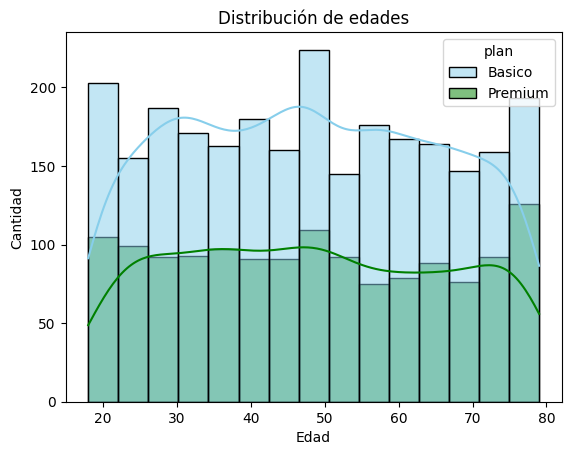

In [116]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=15, palette=['skyblue','green'], kde=True)
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.title('Distribución de edades')
plt.show()

💡Insights: 
- Se observa distribución simétrica, es decir, no presenta sesgos.
- Las distribuciones por edad de cada plan son similares entre sí y tienden a ser simétricas aunque un poco más regular la del plan premium.
- La mayor cantidad de usuarios se concentra alrededor de la edad de 47 a 50 años.
- El plan premium tiene su mayor cantidad de usuarios en el rango de los 75 a 79 años de edad.

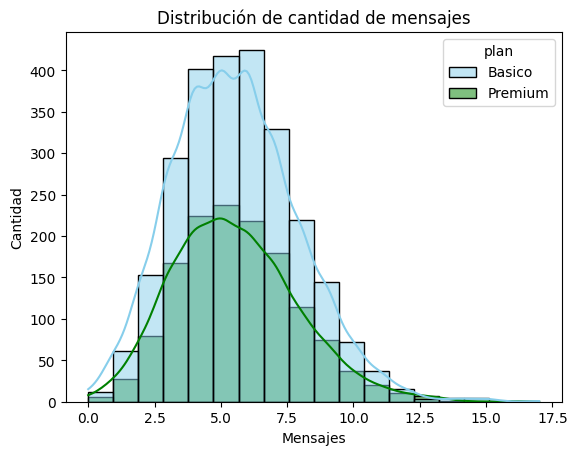

In [117]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=18, palette=['skyblue','green'], kde=True)
plt.xlabel('Mensajes')
plt.ylabel('Cantidad')
plt.title('Distribución de cantidad de mensajes')
plt.show()

💡Insights: 

- Se observa distribución con sesgo leve a la derecha.
- La mayor cantidad de mensajes está alrededor de 5 unidades.
- La proporción de mensajes está distribuída así: 35% para el plan premium y el 65% para el plan básico.

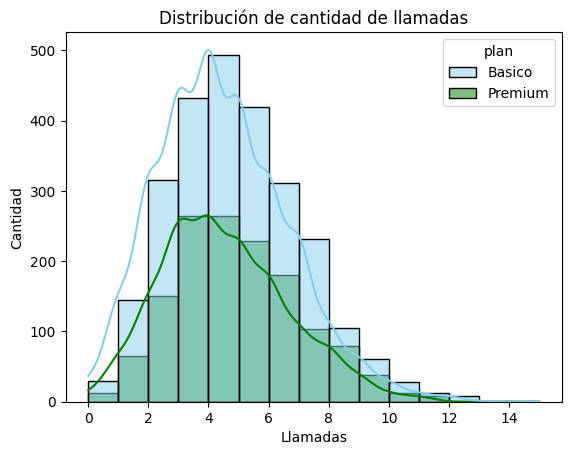

In [118]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=15, palette=['skyblue','green'], kde=True)
plt.xlabel('Llamadas')
plt.ylabel('Cantidad')
plt.title('Distribución de cantidad de llamadas')
plt.show()

💡Insights: 

- Se observa distribución con sesgo a la derecha.
- La mayor cantidad de llamadas está entre 4 y 5 unidades.
- La proporción de llamadas está distribuída en aproximadamente 35% para el plan premium y 65% para el plan básico.

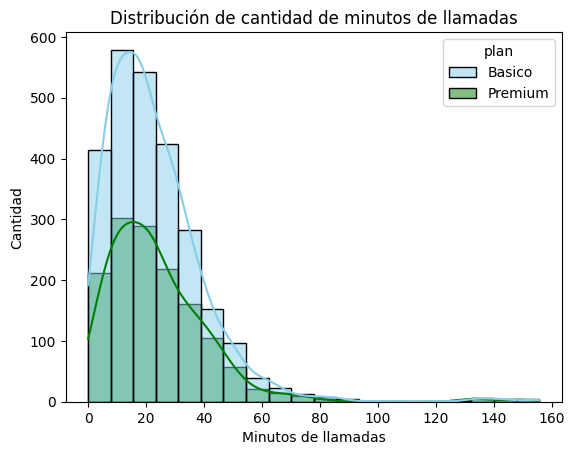

In [119]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=20, palette=['skyblue','green'], kde=True)
plt.xlabel('Minutos de llamadas')
plt.ylabel('Cantidad')
plt.title('Distribución de cantidad de minutos de llamadas')
plt.show()

💡Insights: 
- Se observa distribución con fuerte sesgo a la derecha.
- La mayor cantidad de duración de llamadas en minutos está entre 15 y 20.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

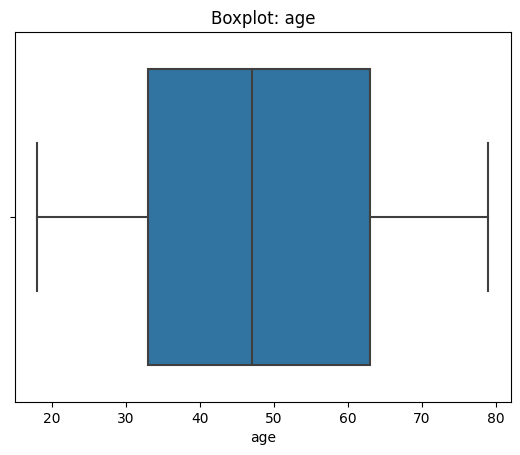

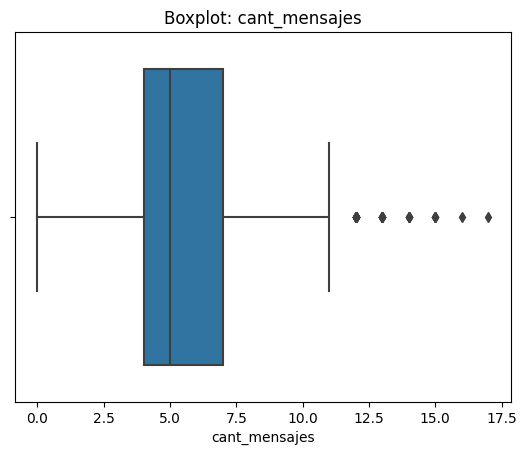

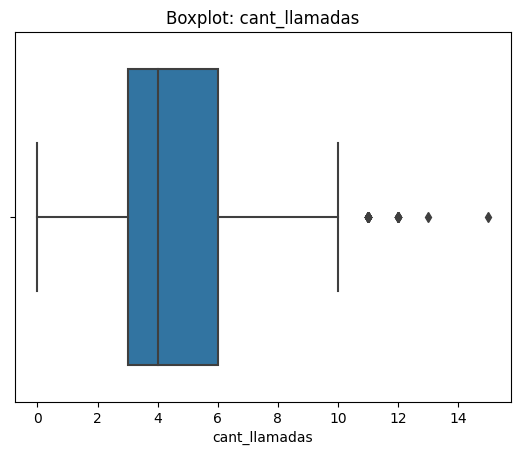

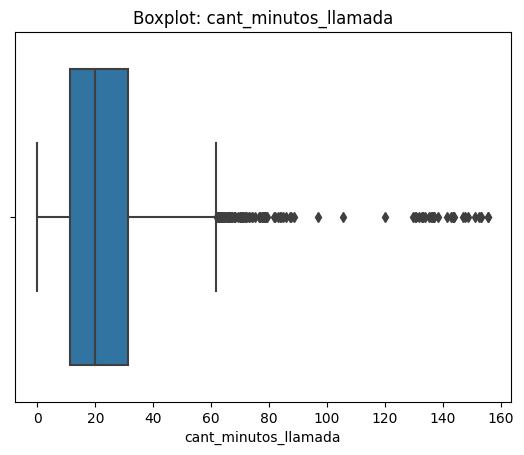

In [120]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Sí presenta outliers
- cant_llamadas: Sí presenta outliers
- cant_minutos_llamada: Sí presenta outliers

In [122]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1_col = user_profile[col].quantile(0.25)
    Q3_col = user_profile[col].quantile(0.75)
    IQR_col = Q3_col - Q1_col

    lim_sup_col = Q3_col + 1.5 * IQR_col
    print(f"El límite superior de la columna {col} es:", lim_sup_col)


El límite superior de la columna cant_mensajes es: 11.5
El límite superior de la columna cant_llamadas es: 10.5
El límite superior de la columna cant_minutos_llamada es: 61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

💡Insights: 
- cant_mensajes: Mantener outliers
- cant_llamadas: Mantener outliers
- cant_minutos_llamada: Mantener outliers

Se deben mantener los outliers en las tres columnas ya que son valores posibles dentro del dataframe (user_profile) debido a que agrupa cantidades por usuario (ver punto 5.1 4.1), es decir, un usuario pudo hacer varias llamadas o enviar varios mensajes generando valores "altos" y allí lo estamos teniendo en cuenta. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [123]:
# Crear columna grupo_uso
def clasificar_segmento(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error en datos"

    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"

    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"

    else:
        return "Alto uso"

user_profile['grupo_uso'] = user_profile.apply(clasificar_segmento, axis=1)


In [124]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [125]:
# Crear columna grupo_edad
def clasificar_segmento_edad(row):
    edad = row['age']
    
    if pd.isna(edad):
        return "Error en datos"

    if edad < 30:
        return "Joven"

    elif edad < 60:
        return "Adulto"

    else:
        return "Adulto Mayor"

user_profile['grupo_edad'] = user_profile.apply(clasificar_segmento_edad, axis=1)

In [126]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

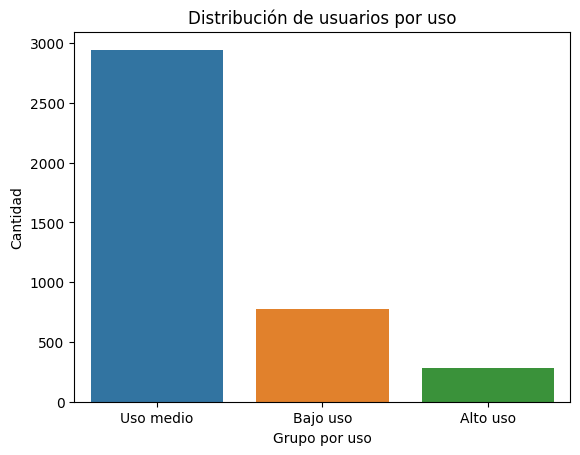

In [131]:
# Visualización de los segmentos por uso
orden = user_profile['grupo_uso'].value_counts().index
sns.countplot(data=user_profile, x='grupo_uso', order = orden)
plt.title('Distribución de usuarios por uso')
plt.xlabel('Grupo por uso')
plt.ylabel('Cantidad')
plt.show()

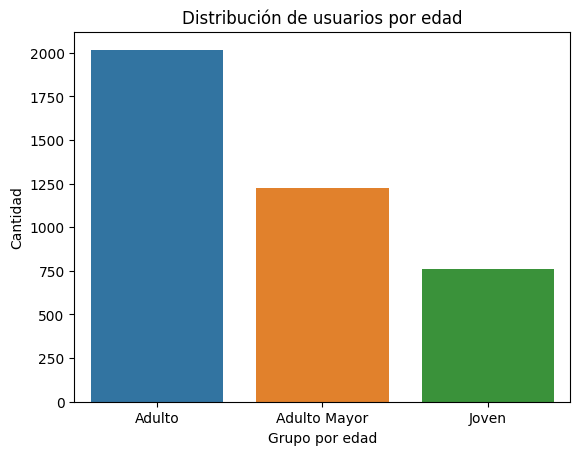

In [135]:
# Visualización de los segmentos por edad
orden1 = user_profile['grupo_edad'].value_counts().index
sns.countplot(data=user_profile, x='grupo_edad', order = orden1)
plt.title('Distribución de usuarios por edad')
plt.xlabel('Grupo por edad')
plt.ylabel('Cantidad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Inicialmente, en el dataset users, se evidenciaron datos inválidos y faltantes puntualmente en la columna edad con valores de -999, en la columna city con valores "?" (469 registros equivalentes al 11%) y en las columnas de fechas como tipo object razones por las cuales se requirió de una posterior limpieza. Adicionalmente, se evidenció la columna churn_date con un porcentaje del 88% de valores nulos pero que se ignoró debido a la naturaleza de dicha columna (fecha de retiro, por lo que sólo el 12% de registros aparecían como retirados).
- De igual manera, en el dataset usage, se tenía la columna date como tipo de dato object.
- En general y adicionalmente, el dataset tenía registros con fechas posteriores a las del periodo de análisis, por lo que posteriormente se le debió dar tratamiento.

🔍 **Segmentos por Edad**
- Se generó segmentación por edad en tres grupos, "joven" para menores de 30 años, "adulto" para edades entre 30 y 60 y "adulto mayor" con edades mayores a 60 años. Respecto a la composición de los clientes, se observa que la mayor proporción es de adultos, seguida de adultos mayores y los jóvenes con la menor participación.   

📊 **Segmentos por Nivel de Uso**
- Frente a la segmentación por niveles de uso, se definieron 3 a partir de la cantidad de llamadas y mensajes que registró cada cliente así: alto (más de 10 llamadas y/o mensajes), medio (entre 5 y 10 llamadas y mensajes) y bajo (menos de 5 llamadas y mensajes). Se evidenció que la mayor proporción corresponde al uso medio, seguida del uso moderado y el alto uso como una parte bastante menor que la de uso medio.

➡️ Esto sugiere que los segmentos "adulto" y "uso medio" son los más representativos para los ingresos de la compañia debido a la proporción que significan aunque los segmentos "joven" y "alto uso" tienen un potencial importante para desarrollar.
Por otra parte, se evidenciaron outliers en cantidad de mensajes, cantidad de llamadas y cantidad de minutos de llamada siendo para ésta última los valores más extremos o alejados de la mediana y que se corresponden con los usuarios de alto uso, situación que refleja la necesidad de algunos clientes de hacer altos volúmenes de llamadas o duración de las mismas.  


💡 **Recomendaciones**
- Se recomienda evaluar la posibilidad de implementar uno o dos planes adicionales que se puedan ajustar más a las necesidades de los clientes.
- Adicionalmente, se recomienda profundizar el análisis para los clientes con planes básicos ya que puede existir la oportunidad de migrarlos a planes premium según sus necesidades.
- Teniendo en cuenta que el segmento jóven de clientes es el de menor participación, evaluar la posibilidad de desarrollar planes más accequibles o con mejores beneficios así como efectuar campañas de mercadeo enfocados a este sector.
- Para finalizar, se sugiere plantear estrategias de fidelización teniendo en cuenta antiguedad y consumos de los clientes con el fin de prevenir posibles retiros.     

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/Wilmer-Bautista/ConnectaTel.git`